<a href="https://colab.research.google.com/github/Shwethababu/Python_projects/blob/shwetha/Major_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
fruit =pd.read_csv("/content/drive/MyDrive/Book1.csv")
fruit


,Unnamed: 0,Unnamed: 1,Unnamed: 2,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,NaN,NaN,NaN,1,apple,granny_smith,192,8.4,7.3,0.55
1,NaN,NaN,NaN,1,apple,granny_smith,180,8.0,6.8,0.59
2,NaN,NaN,NaN,1,apple,granny_smith,176,7.4,7.2,0.60
3,NaN,NaN,NaN,2,mandarin,mandarin,86,6.2,4.7,0.80
4,NaN,NaN,NaN,2,mandarin,mandarin,84,6.0,4.6,0.79
5,NaN,NaN,NaN,2,mandarin,mandarin,80,5.8,4.3,0.77
6,NaN,NaN,NaN,2,mandarin,mandarin,80,5.9,4.3,0.81
7,NaN,NaN,NaN,2,mandarin,mandarin,76,5.8,4.0,0.81
8,NaN,NaN,NaN,1,apple,braeburn,178,7.1,7.8,0.92
9,NaN,NaN,NaN,1,apple,braeburn,172,7.4,7.0,0.89


In [ ]:
fruit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     0 non-null      float64
 1   Unnamed: 1     0 non-null      float64
 2   Unnamed: 2     0 non-null      float64
 3   fruit_label    59 non-null     int64  
 4   fruit_name     59 non-null     object 
 5   fruit_subtype  59 non-null     object 
 6   mass           59 non-null     int64  
 7   width          59 non-null     float64
 8   height         59 non-null     float64
 9   color_score    59 non-null     float64
dtypes: float64(6), int64(2), object(2)
memory usage: 4.7+ KB


In [ ]:
fruit.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,NaN,NaN,NaN,1,apple,granny_smith,192,8.4,7.3,0.55
1,NaN,NaN,NaN,1,apple,granny_smith,180,8.0,6.8,0.59
2,NaN,NaN,NaN,1,apple,granny_smith,176,7.4,7.2,0.60
3,NaN,NaN,NaN,2,mandarin,mandarin,86,6.2,4.7,0.80
4,NaN,NaN,NaN,2,mandarin,mandarin,84,6.0,4.6,0.79


In [ ]:
fruit.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'fruit_label', 'fruit_name',
       'fruit_subtype', 'mass', 'width', 'height', 'color_score'],
      dtype='object')

In [ ]:
lookup_fruit_name = dict(zip(fruit.fruit_label.unique(),fruit.fruit_name.unique()))
lookup_fruit_name

{1: 'apple', 2: 'mandarin', 3: 'orange', 4: 'lemon'}

In [ ]:
from sklearn.model_selection import train_test_split

X = fruit[['mass', 'width', 'height', 'color_score']]
y = fruit['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)



In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn.score(X_test, y_test)

0.5333333333333333

In [ ]:
fruit_prediction = knn.predict([[20, 4.3, 5.5, 0.75]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'mandarin'

In [ ]:
fruit_prediction = knn.predict([[100, 6.3, 8.5, 0.75]])
lookup_fruit_name[fruit_prediction[0]]



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

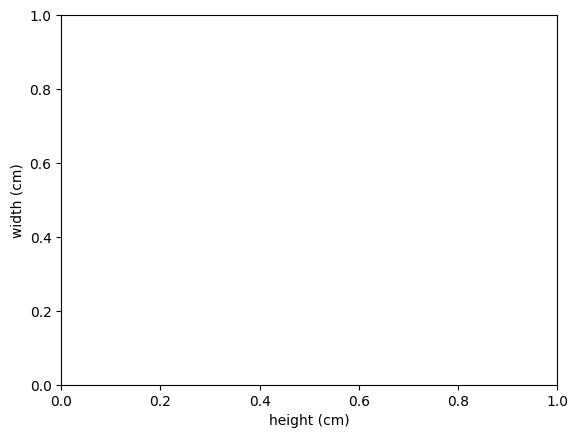

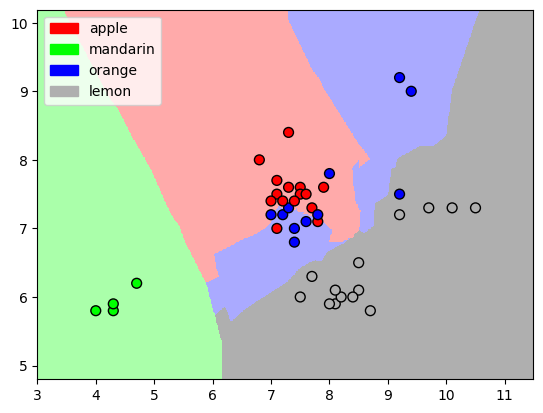

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.patches as mpatches
X = fruit[['mass', 'width', 'height', 'color_score']]
y = fruit['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

def plot_fruit_knn(X, y, n_neighbors, weights):
    X_mat = X[['height', 'width']].values
    y_mat = y.values

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF','#AFAFAF'])
    cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF','#AFAFAF'])
    clf = KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X_mat, y_mat)


    mesh_step_size = .01
    plot_symbol_size = 50

    x_min, x_max = X_mat[:, 0].min() - 1, X_mat[:, 0].max() + 1
    y_min, y_max = X_mat[:, 1].min() - 1, X_mat[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(X_mat[:, 0], X_mat[:, 1], s=plot_symbol_size, c=y, cmap=cmap_bold, edgecolor = 'black')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    patch0 = mpatches.Patch(color='#FF0000', label='apple')
    patch1 = mpatches.Patch(color='#00FF00', label='mandarin')
    patch2 = mpatches.Patch(color='#0000FF', label='orange')
    patch3 = mpatches.Patch(color='#AFAFAF', label='lemon')
    plt.legend(handles=[patch0, patch1, patch2, patch3])
plt.xlabel('height (cm)')
plt.ylabel('width (cm)')

plt.show()
plot_fruit_knn(X_train, y_train, 5, 'uniform')